# Corporate Bankruptcy Prediction Across Forecasting Horizons (1–5 years)

This notebook is a cleaned, reproducible MSc-level implementation addressing supervisor feedback:

- Consistent, correct metric reporting (tables saved to CSV).
- Clear figure provenance (each plot labelled with model + setting).
- No data leakage: preprocessing + SMOTE performed inside cross-validation pipelines.
- Horizon-wise evaluation (1–5 years) with baseline vs tuned comparison.
- Step-6 stability checks: dataset size, bankruptcy rate, and cross-validated AUC with error bars.
- Explainability on **raw financial ratios (Attr1–Attr64)** using SHAP (PCA treated as optional ablation only).

Run cells in order.

## 0. Setup

In [1]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

warnings.filterwarnings("ignore")
np.random.seed(42)

OUTPUT_DIR = "outputs_bankruptcy"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

RANDOM_STATE = 42

# Runtime control: set FAST_MODE=True for quicker runs on 8GB machines.
FAST_MODE = True
N_JOBS = 1


## 1. Data loading (ARFF)

Edit `DATA_PATHS` if your files are elsewhere. The repository provides 1year–5year datasets, each with 64 ratio features and the target column `class`.

In [2]:
DATA_PATHS = {
    "1year": "1year.arff",
    "2year": "2year.arff",
    "3year": "3year.arff",
    "4year": "4year.arff",
    "5year": "5year.arff",
}

# If files are not in the notebook folder (e.g., Colab / sandbox), fall back to /mnt/data.
CANDIDATE_PATHS = [
    DATA_PATHS,
    {k: os.path.join("/mnt/data", v) for k, v in DATA_PATHS.items()},
]

DATA_PATHS = None
for cand in CANDIDATE_PATHS:
    if all(os.path.exists(p) for p in cand.values()):
        DATA_PATHS = cand
        break

if DATA_PATHS is None:
    raise FileNotFoundError("ARFF files not found. Put 1year.arff..5year.arff next to this notebook or update DATA_PATHS.")

def load_arff_file(path: str) -> pd.DataFrame:
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    # Decode bytes in ARFF nominal fields (if any)
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

    if "class" not in df.columns:
        raise ValueError(f"Expected 'class' column not found in {path}")

    df["class"] = pd.to_numeric(df["class"], errors="coerce").astype(int)

    # Ensure features numeric
    feature_cols = [c for c in df.columns if c != "class"]
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

    return df

datasets = {h: load_arff_file(p) for h, p in DATA_PATHS.items()}

for h, df in datasets.items():
    rate = df["class"].mean()
    print(h, "shape=", df.shape, "bankruptcy_rate=", round(rate, 4))

1year shape= (7027, 65) bankruptcy_rate= 0.0386
2year shape= (10173, 65) bankruptcy_rate= 0.0393
3year shape= (10503, 65) bankruptcy_rate= 0.0471
4year shape= (9792, 65) bankruptcy_rate= 0.0526
5year shape= (5910, 65) bankruptcy_rate= 0.0694


## 2. Dataset description: attribute list (Attr1–Attr64)

Supervisor feedback requires you to list attribute meanings in the report. Below is the official mapping (UCI / commonly distributed readme). You can copy this table into Chapter 3 of your report.

In [3]:

attr_map = [
("Attr1","net profit / total assets"),
("Attr2","total liabilities / total assets"),
("Attr3","working capital / total assets"),
("Attr4","current assets / short-term liabilities"),
("Attr5","[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365"),
("Attr6","retained earnings / total assets"),
("Attr7","EBIT / total assets"),
("Attr8","book value of equity / total liabilities"),
("Attr9","sales / total assets"),
("Attr10","equity / total assets"),
("Attr11","(gross profit + extraordinary items + financial expenses) / total assets"),
("Attr12","gross profit / short-term liabilities"),
("Attr13","(gross profit + depreciation) / sales"),
("Attr14","(gross profit + interest) / total assets"),
("Attr15","(total liabilities * 365) / (gross profit + depreciation)"),
("Attr16","(gross profit + depreciation) / total liabilities"),
("Attr17","total assets / total liabilities"),
("Attr18","gross profit / total assets"),
("Attr19","gross profit / sales"),
("Attr20","(inventory * 365) / sales"),
("Attr21","sales (n) / sales (n-1)"),
("Attr22","profit on operating activities / total assets"),
("Attr23","net profit / sales"),
("Attr24","gross profit (in 3 years) / total assets"),
("Attr25","(equity - share capital) / total assets"),
("Attr26","(net profit + depreciation) / total liabilities"),
("Attr27","profit on operating activities / financial expenses"),
("Attr28","working capital / fixed assets"),
("Attr29","logarithm of total assets"),
("Attr30","(total liabilities - cash) / sales"),
("Attr31","(gross profit + interest) / sales"),
("Attr32","(current liabilities * 365) / cost of products sold"),
("Attr33","operating expenses / short-term liabilities"),
("Attr34","operating expenses / total liabilities"),
("Attr35","profit on sales / total assets"),
("Attr36","total sales / total assets"),
("Attr37","(current assets - inventories) / long-term liabilities"),
("Attr38","constant capital / total assets"),
("Attr39","profit on sales / sales"),
("Attr40","(current assets - inventory - receivables) / short-term liabilities"),
("Attr41","total liabilities / ((profit on operating activities + depreciation) * (12/365))"),
("Attr42","profit on operating activities / sales"),
("Attr43","rotation receivables + inventory turnover in days"),
("Attr44","(receivables * 365) / sales"),
("Attr45","net profit / inventory"),
("Attr46","(current assets - inventory) / short-term liabilities"),
("Attr47","(inventory * 365) / cost of products sold"),
("Attr48","EBITDA (profit on operating activities - depreciation) / total assets"),
("Attr49","EBITDA (profit on operating activities - depreciation) / sales"),
("Attr50","current assets / total liabilities"),
("Attr51","short-term liabilities / total assets"),
("Attr52","(short-term liabilities * 365) / cost of products sold"),
("Attr53","equity / fixed assets"),
("Attr54","constant capital / fixed assets"),
("Attr55","working capital"),
("Attr56","(sales - cost of products sold) / sales"),
("Attr57","(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation)"),
("Attr58","total costs / total sales"),
("Attr59","long-term liabilities / equity"),
("Attr60","sales / inventory"),
("Attr61","sales / receivables"),
("Attr62","(short-term liabilities * 365) / sales"),
("Attr63","sales / short-term liabilities"),
("Attr64","sales / fixed assets"),
]
attr_df = pd.DataFrame(attr_map, columns=["Attribute","Meaning"])
attr_df.to_csv(os.path.join(TAB_DIR, "attribute_definitions.csv"), index=False)
attr_df.head(10)


,Attribute,Meaning
0,Attr1,net profit / total assets
1,Attr2,total liabilities / total assets
2,Attr3,working capital / total assets
3,Attr4,current assets / short-term liabilities
4,Attr5,[(cash + short-term securities + receivables -...
5,Attr6,retained earnings / total assets
6,Attr7,EBIT / total assets
7,Attr8,book value of equity / total liabilities
8,Attr9,sales / total assets
9,Attr10,equity / total assets


## 3. EDA (distinction-level)

This section produces:
- Summary table per horizon (rows, features, missingness, bankruptcy rate)
- Missingness bar plot and top-missing features
- Class imbalance plot
- Correlation heatmap (top 20 features by absolute correlation with target)

In [4]:

def dataset_summary(df: pd.DataFrame, horizon: str) -> dict:
    n_rows, n_cols = df.shape
    missing_total = int(df.isna().sum().sum())
    missing_pct = float(missing_total / (n_rows * n_cols) * 100.0)
    bankrupt_rate = float(df["class"].mean() * 100.0)
    return {
        "Horizon": horizon,
        "Rows": n_rows,
        "Columns": n_cols,
        "Features": n_cols - 1,
        "MissingTotal": missing_total,
        "MissingPct": missing_pct,
        "BankruptcyRatePct": bankrupt_rate,
    }

summary_rows = [dataset_summary(df, h) for h, df in datasets.items()]
summary_df = pd.DataFrame(summary_rows).sort_values("Horizon").reset_index(drop=True)
summary_df.to_csv(os.path.join(TAB_DIR, "dataset_summary.csv"), index=False)
summary_df


,Horizon,Rows,Columns,Features,MissingTotal,MissingPct,BankruptcyRatePct
0,1year,7027,65,64,5835,1.277490,3.856553
1,2year,10173,65,64,12157,1.838502,3.931977
2,3year,10503,65,64,9888,1.448377,4.712939
3,4year,9792,65,64,8776,1.378834,5.259395
4,5year,5910,65,64,4666,1.214630,6.937394


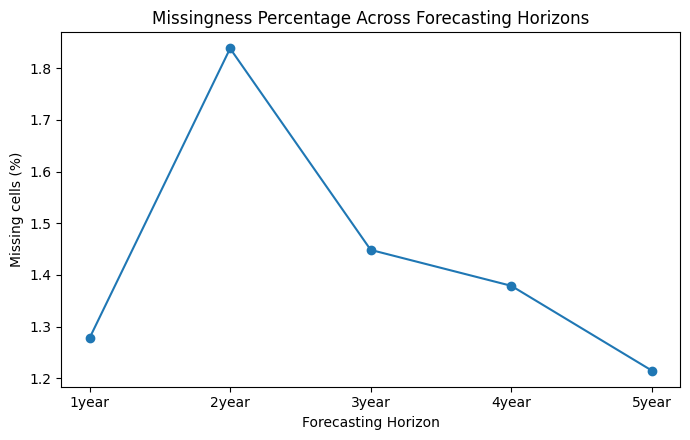

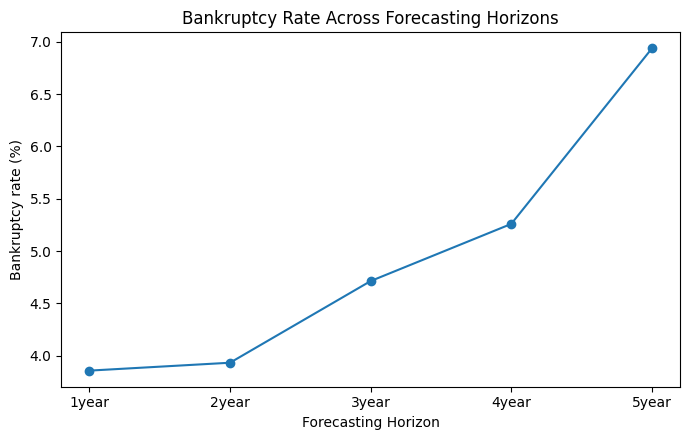

In [5]:

# Missing values across horizons
plt.figure(figsize=(7,4.5))
plt.plot(summary_df["Horizon"], summary_df["MissingPct"], marker="o")
plt.title("Missingness Percentage Across Forecasting Horizons")
plt.xlabel("Forecasting Horizon")
plt.ylabel("Missing cells (%)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_missingness_pct_by_horizon.png"), dpi=300)
plt.show()

# Class imbalance across horizons
plt.figure(figsize=(7,4.5))
plt.plot(summary_df["Horizon"], summary_df["BankruptcyRatePct"], marker="o")
plt.title("Bankruptcy Rate Across Forecasting Horizons")
plt.xlabel("Forecasting Horizon")
plt.ylabel("Bankruptcy rate (%)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_bankruptcy_rate_by_horizon.png"), dpi=300)
plt.show()


In [6]:

# Top missing features (per horizon)
top_missing_rows = []
for h, df in datasets.items():
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    for feat, cnt in miss.items():
        top_missing_rows.append({"Horizon": h, "Feature": feat, "MissingCount": int(cnt)})

top_missing_df = pd.DataFrame(top_missing_rows)
top_missing_df.to_csv(os.path.join(TAB_DIR, "top_missing_features.csv"), index=False)
top_missing_df.head(12)


,Horizon,Feature,MissingCount
0,1year,Attr37,2740
1,1year,Attr21,1622
2,1year,Attr27,311
3,1year,Attr60,135
4,1year,Attr45,134
5,1year,Attr24,124
6,1year,Attr41,84
7,1year,Attr11,39
8,1year,Attr32,38
9,1year,Attr28,34


## 4. Baseline model (logistic regression) and baseline boosting (LightGBM)

These are used to:
- Provide an interpretable baseline
- Replicate the AUC figures you already generated

The results are saved to CSV so your report numbers always match the code outputs.

In [7]:

from sklearn.linear_model import LogisticRegression

def eval_holdout_auc(model_pipe, X_train, y_train, X_test, y_test) -> dict:
    model_pipe.fit(X_train, y_train)
    prob = model_pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "AUC": float(roc_auc_score(y_test, prob)),
        "Accuracy": float(accuracy_score(y_test, pred)),
        "Precision": float(precision_score(y_test, pred, zero_division=0)),
        "Recall": float(recall_score(y_test, pred, zero_division=0)),
        "F1": float(f1_score(y_test, pred, zero_division=0)),
    }

baseline_rows = []

for h, df in datasets.items():
    X = df.drop(columns=["class"])
    y = df["class"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    # Logistic regression baseline (imbalance-aware)
    lr_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ])
    lr_metrics = eval_holdout_auc(lr_pipe, X_train, y_train, X_test, y_test)
    baseline_rows.append({"Horizon": h, "Model": "LogisticRegression", **lr_metrics})

    # LightGBM baseline (no SMOTE here; use class_weight strategy via is_unbalance)
    lgb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LGBMClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=1,
            verbose=-1,
            is_unbalance=True
        )),
    ])
    lgb_metrics = eval_holdout_auc(lgb_pipe, X_train, y_train, X_test, y_test)
    baseline_rows.append({"Horizon": h, "Model": "LightGBM_Baseline", **lgb_metrics})

baseline_df = pd.DataFrame(baseline_rows).sort_values(["Model","Horizon"]).reset_index(drop=True)
baseline_df.to_csv(os.path.join(TAB_DIR, "baseline_holdout_metrics.csv"), index=False)
baseline_df


,Horizon,Model,AUC,Accuracy,Precision,Recall,F1
0,1year,LightGBM_Baseline,0.978975,0.985064,0.945946,0.648148,0.769231
1,2year,LightGBM_Baseline,0.930505,0.979853,0.867925,0.575000,0.691729
2,3year,LightGBM_Baseline,0.923148,0.964303,0.676471,0.464646,0.550898
3,4year,LightGBM_Baseline,0.914996,0.965799,0.790323,0.475728,0.593939
4,5year,LightGBM_Baseline,0.962173,0.961929,0.784615,0.621951,0.693878
5,1year,LogisticRegression,0.713511,0.677098,0.072650,0.629630,0.130268
6,2year,LogisticRegression,0.679591,0.635872,0.071336,0.687500,0.129260
7,3year,LogisticRegression,0.742053,0.658734,0.093421,0.717172,0.165308
8,4year,LogisticRegression,0.717442,0.770291,0.125270,0.563107,0.204947
9,5year,LogisticRegression,0.819479,0.810491,0.220472,0.682927,0.333333


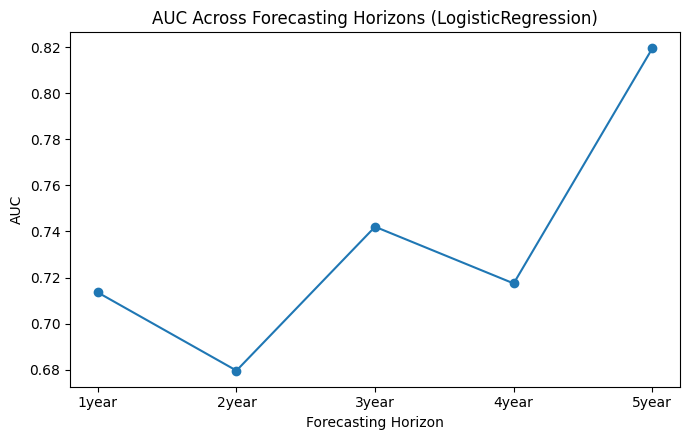

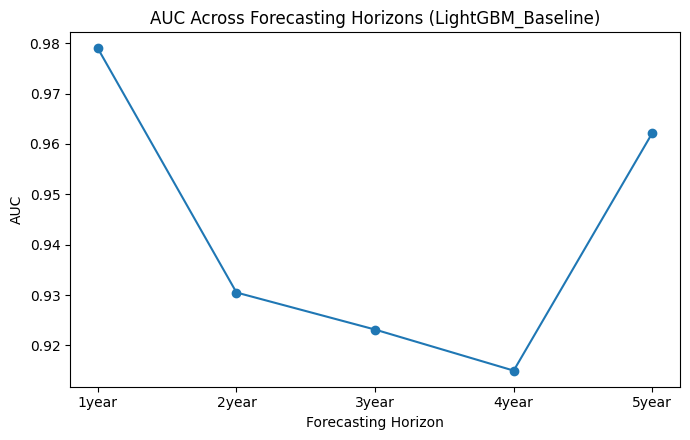

In [8]:

# Plot: AUC across horizons (baseline)
def plot_auc_trend(df, model_name, fname):
    d = df[df["Model"] == model_name].sort_values("Horizon")
    plt.figure(figsize=(7,4.5))
    plt.plot(d["Horizon"], d["AUC"], marker="o")
    plt.title(f"AUC Across Forecasting Horizons ({model_name})")
    plt.xlabel("Forecasting Horizon")
    plt.ylabel("AUC")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300)
    plt.show()

plot_auc_trend(baseline_df, "LogisticRegression", "fig_auc_logreg_baseline.png")
plot_auc_trend(baseline_df, "LightGBM_Baseline", "fig_auc_lightgbm_baseline.png")


## 5. Main methodology: Baseline vs Tuned (XGBoost, LightGBM, CatBoost)

Key fixes vs your previous submission:

- No PCA in main pipeline, so SHAP refers to **real financial ratios**.
- SMOTE is applied inside cross-validation via `ImbPipeline` to avoid leakage.
- Figures are generated from the saved results table to avoid mismatches.

Compute note: `N_ITER` is kept modest for 8GB machines. Increase if you have more time/compute.

In [9]:

N_ITER = 8 if FAST_MODE else 20   # tuning iterations
N_JOBS = 1

cv = RepeatedStratifiedKFold(n_splits=3 if FAST_MODE else 5, n_repeats=1, random_state=RANDOM_STATE)

def make_models():
    return {
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=1
        ),
        "LightGBM": LGBMClassifier(
            random_state=RANDOM_STATE,
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=1,
            verbose=-1,
            is_unbalance=False
        ),
        "CatBoost": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            iterations=600,
            learning_rate=0.05,
            depth=6
        ),
    }

def make_imb_pipeline(model):
    return ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

def param_space(name: str):
    if name == "XGBoost":
        return {
            "model__n_estimators": [200, 400, 700],
            "model__max_depth": [3, 4, 6],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
            "model__min_child_weight": [1, 3, 6],
            "model__gamma": [0.0, 0.5, 1.0],
        }
    if name == "LightGBM":
        return {
            "model__n_estimators": [200, 500, 900],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__min_child_samples": [10, 30, 80],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
            "model__reg_alpha": [0.0, 0.5, 1.0],
            "model__reg_lambda": [0.0, 1.0, 3.0],
        }
    if name == "CatBoost":
        return {
            "model__iterations": [300, 600, 1000],
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__l2_leaf_reg": [1.0, 3.0, 7.0, 12.0],
        }
    raise ValueError("Unknown model name")

def run_horizon(df: pd.DataFrame, horizon: str):
    X = df.drop(columns=["class"])
    y = df["class"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    rows = []
    best_models = {}

    for name, model in make_models().items():
        # Baseline
        base_pipe = make_imb_pipeline(model)
        base_pipe.fit(X_train, y_train)
        base_prob = base_pipe.predict_proba(X_test)[:, 1]
        base_auc = roc_auc_score(y_test, base_prob)
        rows.append({"Horizon": horizon, "Model": name, "Variant": "Baseline", "AUC": float(base_auc)})

        # Tuned
        search = RandomizedSearchCV(
            estimator=make_imb_pipeline(model),
            param_distributions=param_space(name),
            n_iter=N_ITER,
            scoring="roc_auc",
            cv=cv,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            verbose=0
        )
        search.fit(X_train, y_train)
        tuned_pipe = search.best_estimator_
        tuned_prob = tuned_pipe.predict_proba(X_test)[:, 1]
        tuned_auc = roc_auc_score(y_test, tuned_prob)
        rows.append({"Horizon": horizon, "Model": name, "Variant": "Tuned", "AUC": float(tuned_auc)})

        best_models[(horizon, name)] = tuned_pipe

        print("Completed", horizon, name, "BaselineAUC=", round(base_auc,4), "TunedAUC=", round(tuned_auc,4))

    res_df = pd.DataFrame(rows)
    return res_df, best_models

all_rows = []
best_store = {}
for h, df in datasets.items():
    res_df, best_dict = run_horizon(df, h)
    all_rows.append(res_df)
    best_store.update(best_dict)

results_df = pd.concat(all_rows, ignore_index=True)
results_df.to_csv(os.path.join(TAB_DIR, "auc_baseline_vs_tuned.csv"), index=False)
results_df.head(10)


Completed 1year XGBoost BaselineAUC= 0.9654 TunedAUC= 0.9801
Completed 1year LightGBM BaselineAUC= 0.9765 TunedAUC= 0.9777
Completed 1year CatBoost BaselineAUC= 0.965 TunedAUC= 0.9712
Completed 2year XGBoost BaselineAUC= 0.9045 TunedAUC= 0.9113
Completed 2year LightGBM BaselineAUC= 0.9113 TunedAUC= 0.9155
Completed 2year CatBoost BaselineAUC= 0.9052 TunedAUC= 0.9031
Completed 3year XGBoost BaselineAUC= 0.8975 TunedAUC= 0.9008
Completed 3year LightGBM BaselineAUC= 0.9065 TunedAUC= 0.91
Completed 3year CatBoost BaselineAUC= 0.8957 TunedAUC= 0.8995
Completed 4year XGBoost BaselineAUC= 0.8852 TunedAUC= 0.9029
Completed 4year LightGBM BaselineAUC= 0.8941 TunedAUC= 0.9114
Completed 4year CatBoost BaselineAUC= 0.8837 TunedAUC= 0.8882
Completed 5year XGBoost BaselineAUC= 0.9293 TunedAUC= 0.9294
Completed 5year LightGBM BaselineAUC= 0.9397 TunedAUC= 0.9437
Completed 5year CatBoost BaselineAUC= 0.9392 TunedAUC= 0.9435


,Horizon,Model,Variant,AUC
0,1year,XGBoost,Baseline,0.965401
1,1year,XGBoost,Tuned,0.980084
2,1year,LightGBM,Baseline,0.976496
3,1year,LightGBM,Tuned,0.977687
4,1year,CatBoost,Baseline,0.965045
5,1year,CatBoost,Tuned,0.971195
6,2year,XGBoost,Baseline,0.904520
7,2year,XGBoost,Tuned,0.911253
8,2year,LightGBM,Baseline,0.911311
9,2year,LightGBM,Tuned,0.915473


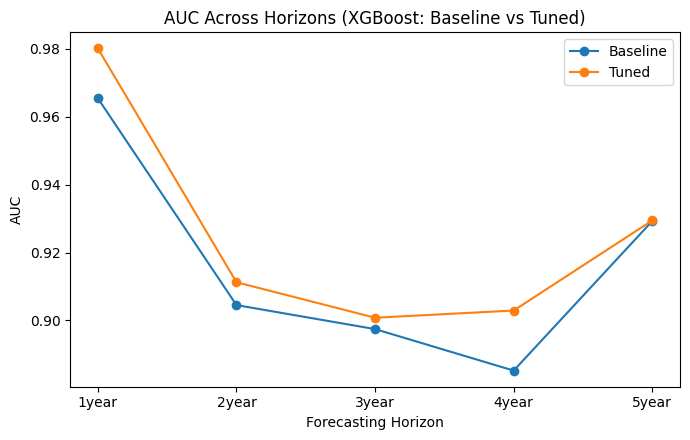

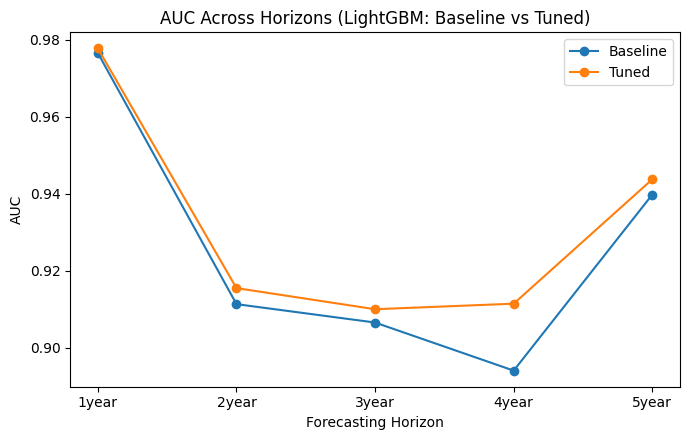

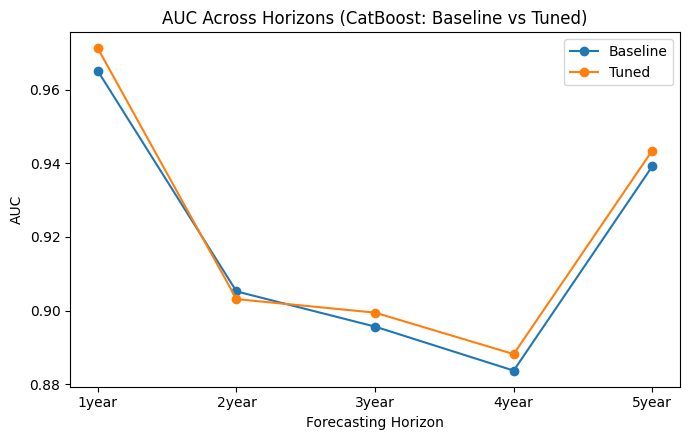

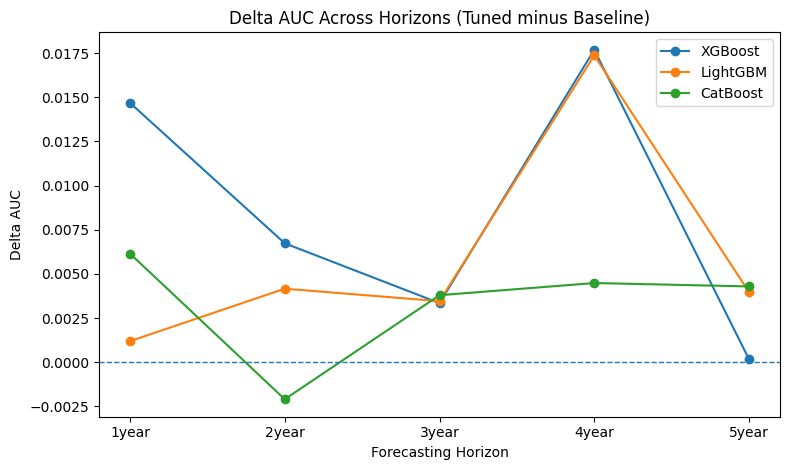

In [10]:

# Figure: Baseline vs Tuned AUC (per horizon) - fixes earlier report inconsistency by plotting from saved table
pivot = results_df.pivot_table(index=["Horizon","Model"], columns="Variant", values="AUC").reset_index()
pivot["DeltaAUC"] = pivot["Tuned"] - pivot["Baseline"]
pivot.to_csv(os.path.join(TAB_DIR, "auc_pivot_delta.csv"), index=False)

# Line plot per model
for model_name in ["XGBoost","LightGBM","CatBoost"]:
    d = results_df[results_df["Model"] == model_name].sort_values(["Variant","Horizon"])
    plt.figure(figsize=(7,4.5))
    for variant in ["Baseline","Tuned"]:
        dv = d[d["Variant"] == variant].sort_values("Horizon")
        plt.plot(dv["Horizon"], dv["AUC"], marker="o", label=variant)
    plt.title(f"AUC Across Horizons ({model_name}: Baseline vs Tuned)")
    plt.xlabel("Forecasting Horizon")
    plt.ylabel("AUC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"fig_auc_{model_name.lower()}_baseline_vs_tuned.png"), dpi=300)
    plt.show()

# Heatmap-like table saved (use in report)
pivot

# Additional figure: Delta AUC (Tuned - Baseline) per horizon for each model
plt.figure(figsize=(8,4.8))
for model_name in ["XGBoost","LightGBM","CatBoost"]:
    pdm = pivot[pivot["Model"] == model_name].sort_values("Horizon")
    plt.plot(pdm["Horizon"], pdm["DeltaAUC"], marker="o", label=model_name)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("Delta AUC Across Horizons (Tuned minus Baseline)")
plt.xlabel("Forecasting Horizon")
plt.ylabel("Delta AUC")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_auc_delta_all_models.png"), dpi=300)
plt.show()


## 6. Step-6 stability checks (requested by supervisor)

This section produces three outputs:
1) Dataset size vs horizon
2) Bankruptcy rate vs horizon
3) Cross-validated AUC with error bars (LightGBM baseline)

Include these in the report to justify horizon effects and avoid overclaiming.

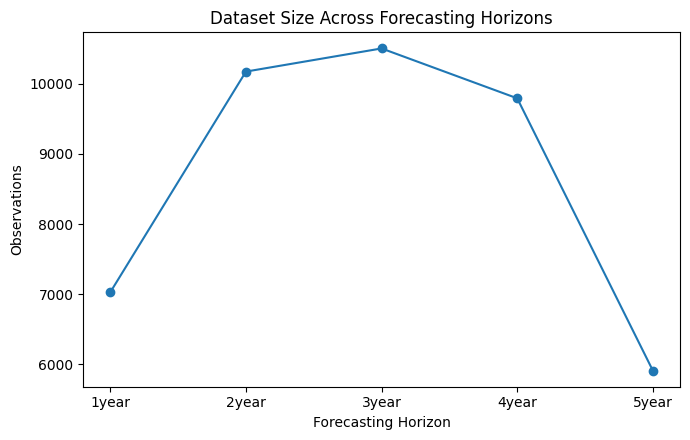

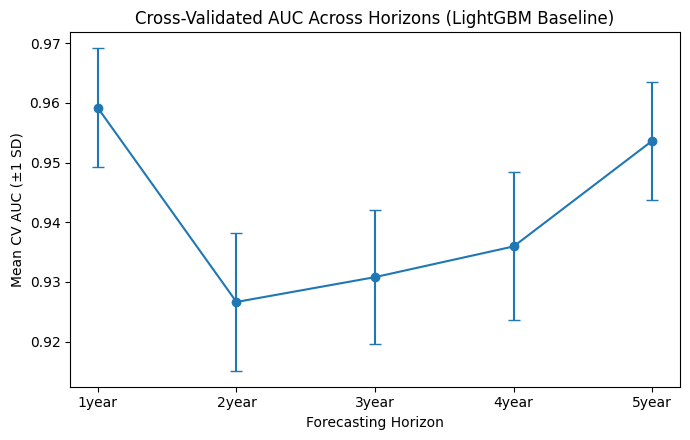

,Horizon,MeanCVAUC,StdCVAUC
0,1year,0.959153,0.009971
1,2year,0.926644,0.011502
2,3year,0.930808,0.011215
3,4year,0.935954,0.012395
4,5year,0.953653,0.009859


In [11]:

# 6.1 + 6.2 already summarised; plot size
plt.figure(figsize=(7,4.5))
plt.plot(summary_df["Horizon"], summary_df["Rows"], marker="o")
plt.title("Dataset Size Across Forecasting Horizons")
plt.xlabel("Forecasting Horizon")
plt.ylabel("Observations")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_step6_dataset_size.png"), dpi=300)
plt.show()

# 6.3 CV AUC for LightGBM baseline (no SMOTE to reduce leakage risk and compute)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for h, df in datasets.items():
    X = df.drop(columns=["class"])
    y = df["class"]
    lgb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LGBMClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=1,
            verbose=-1,
            is_unbalance=True
        )),
    ])
    scores = cross_val_score(lgb_pipe, X, y, scoring="roc_auc", cv=cv5, n_jobs=1)
    cv_rows.append({"Horizon": h, "MeanCVAUC": float(np.mean(scores)), "StdCVAUC": float(np.std(scores))})

cv_df = pd.DataFrame(cv_rows).sort_values("Horizon").reset_index(drop=True)
cv_df.to_csv(os.path.join(TAB_DIR, "cv_auc_lightgbm_baseline.csv"), index=False)

plt.figure(figsize=(7,4.5))
plt.errorbar(cv_df["Horizon"], cv_df["MeanCVAUC"], yerr=cv_df["StdCVAUC"], marker="o", capsize=4)
plt.title("Cross-Validated AUC Across Horizons (LightGBM Baseline)")
plt.xlabel("Forecasting Horizon")
plt.ylabel("Mean CV AUC (±1 SD)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_step6_cv_auc_lightgbm.png"), dpi=300)
plt.show()

cv_df


## 7. Confusion matrices and ROC curves for selected best tuned models

Fixes earlier duplication issue by saving per-horizon per-model figures with unique filenames.

<Figure size 500x450 with 0 Axes>

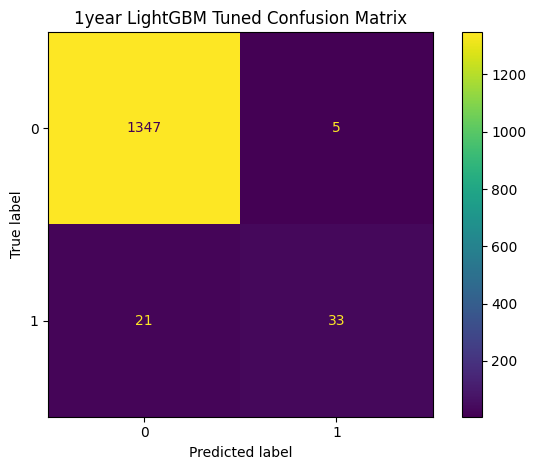

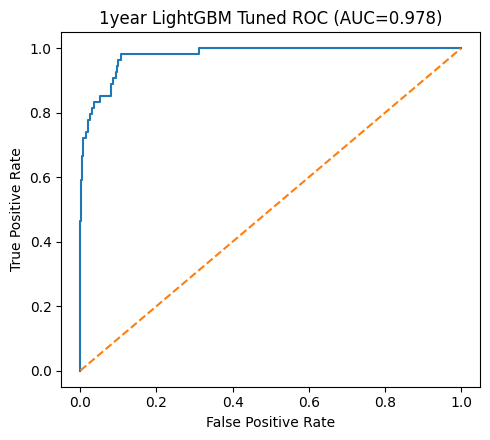

<Figure size 500x450 with 0 Axes>

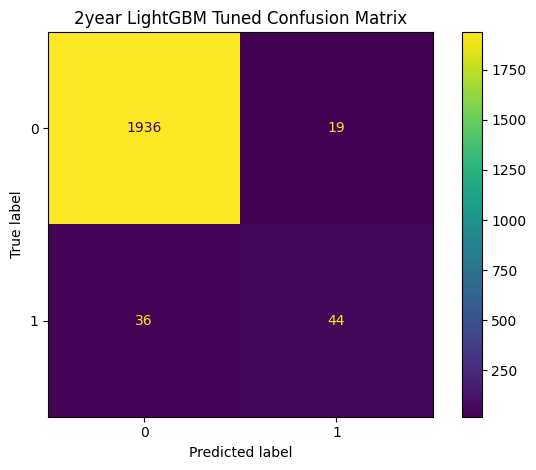

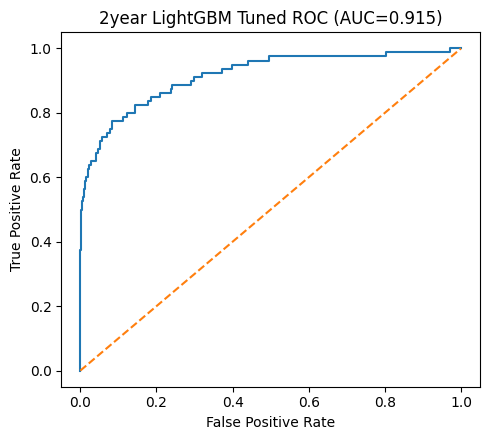

<Figure size 500x450 with 0 Axes>

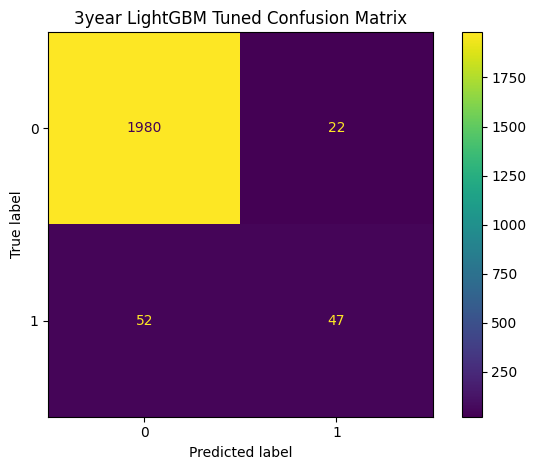

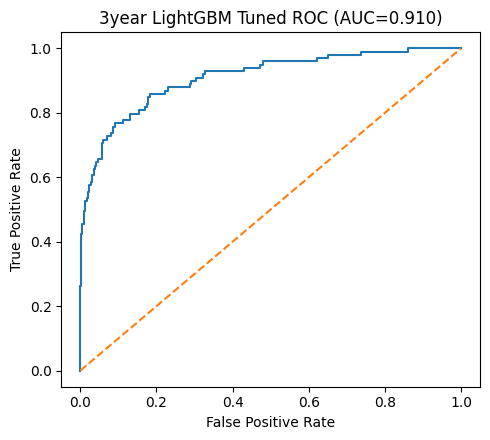

<Figure size 500x450 with 0 Axes>

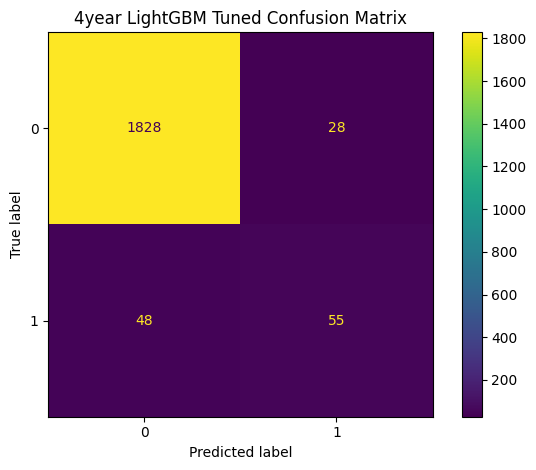

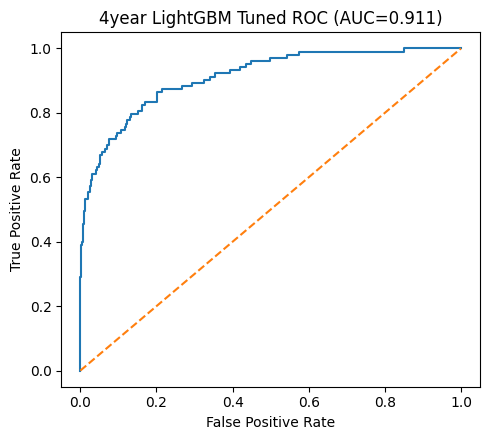

<Figure size 500x450 with 0 Axes>

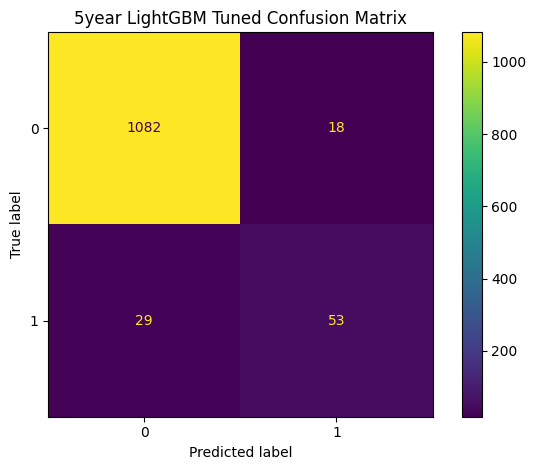

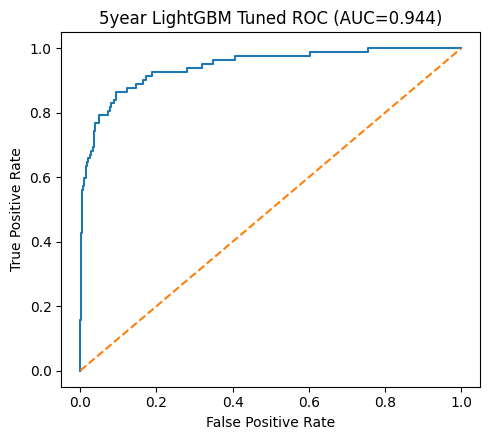

In [12]:

from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_and_roc(pipe, X_train, y_train, X_test, y_test, title_prefix, fname_prefix):
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(5,4.5))
    disp.plot(values_format="d")
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{fname_prefix}_confusion_matrix.png"), dpi=300)
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.figure(figsize=(5,4.5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title(f"{title_prefix} ROC (AUC={auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{fname_prefix}_roc_curve.png"), dpi=300)
    plt.show()

# Example: best tuned LightGBM per horizon (edit if another model best)
for h, df in datasets.items():
    X = df.drop(columns=["class"])
    y = df["class"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    tuned_pipe = best_store[(h, "LightGBM")]
    plot_confusion_and_roc(
        tuned_pipe, X_train, y_train, X_test, y_test,
        title_prefix=f"{h} LightGBM Tuned",
        fname_prefix=f"{h}_lightgbm_tuned"
    )


## 8. SHAP explainability on raw financial ratios (addresses abstract + supervisor feedback)

This fixes the earlier report issue where SHAP was performed on PCA components, making it impossible to name influential financial indicators. Here we compute SHAP on the **original Attr features**.

To keep runtime manageable, we:
- Use a stratified sample of the training data for SHAP
- Explain the tuned LightGBM model for each horizon (or select the overall best horizon model).

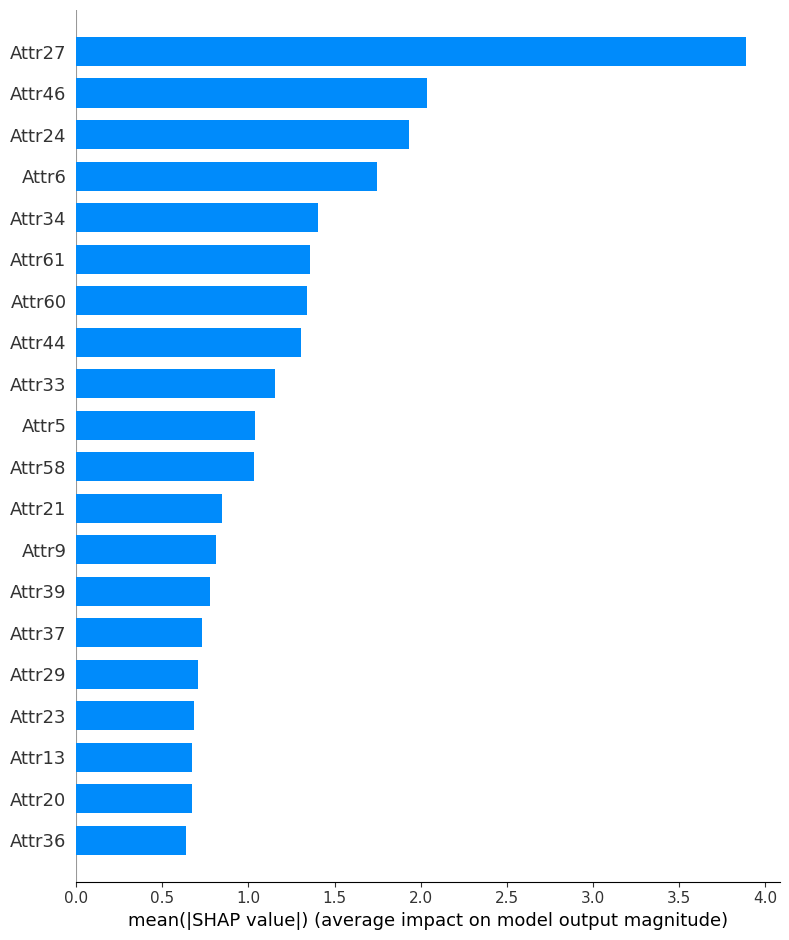

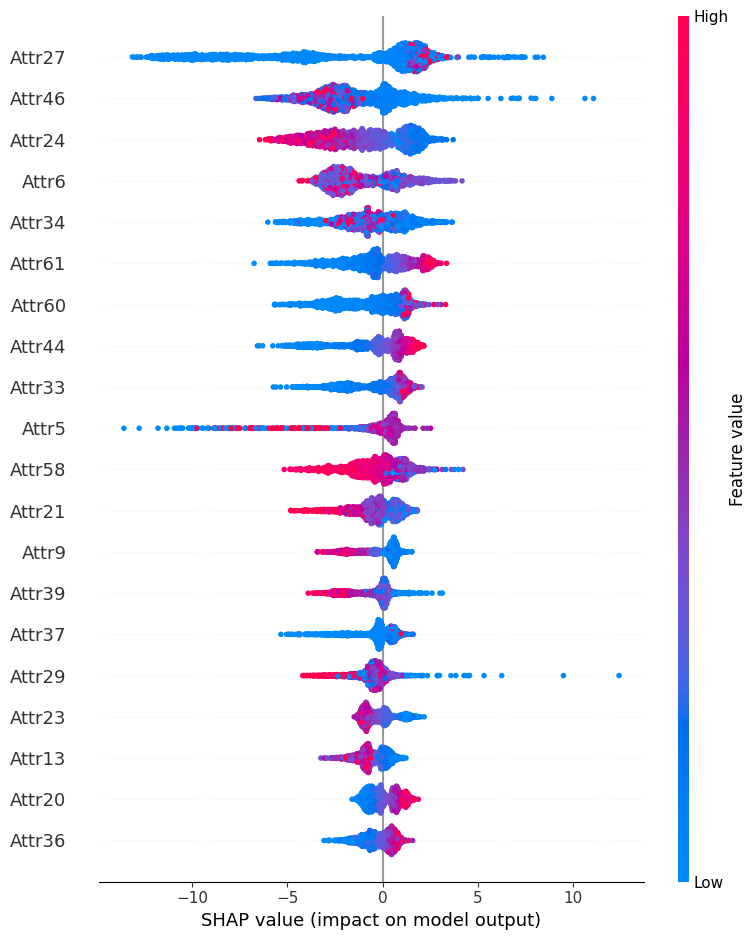

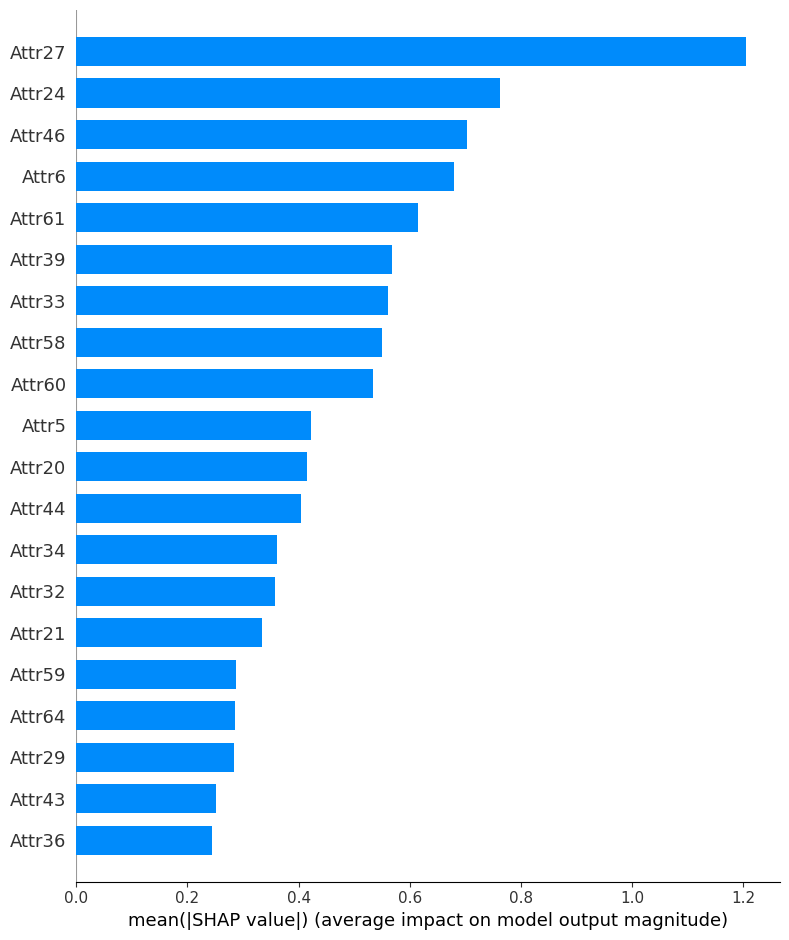

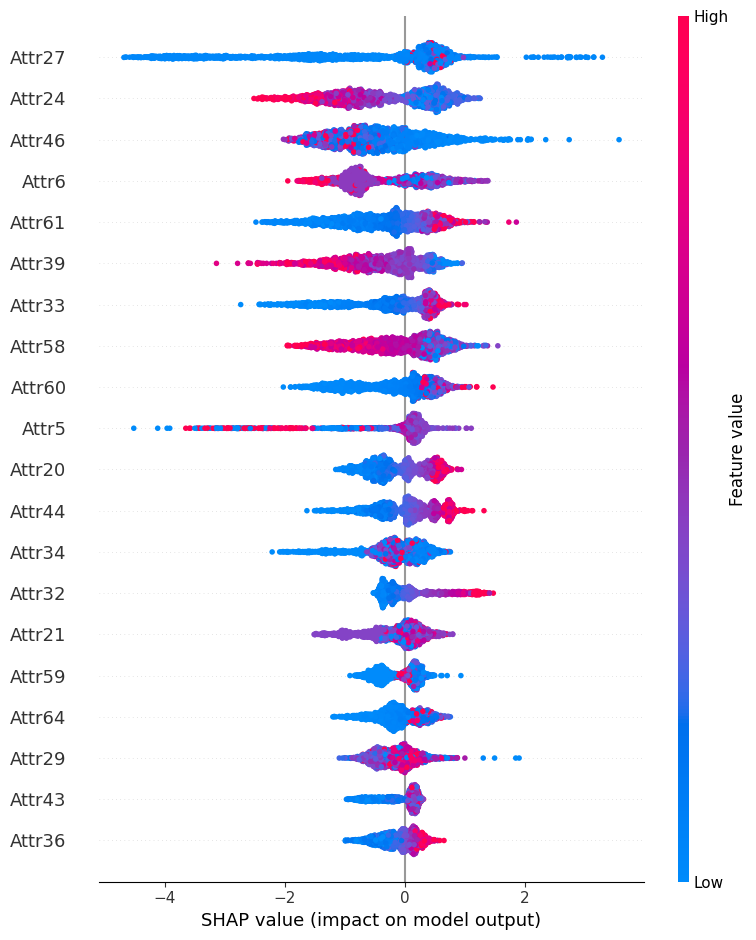

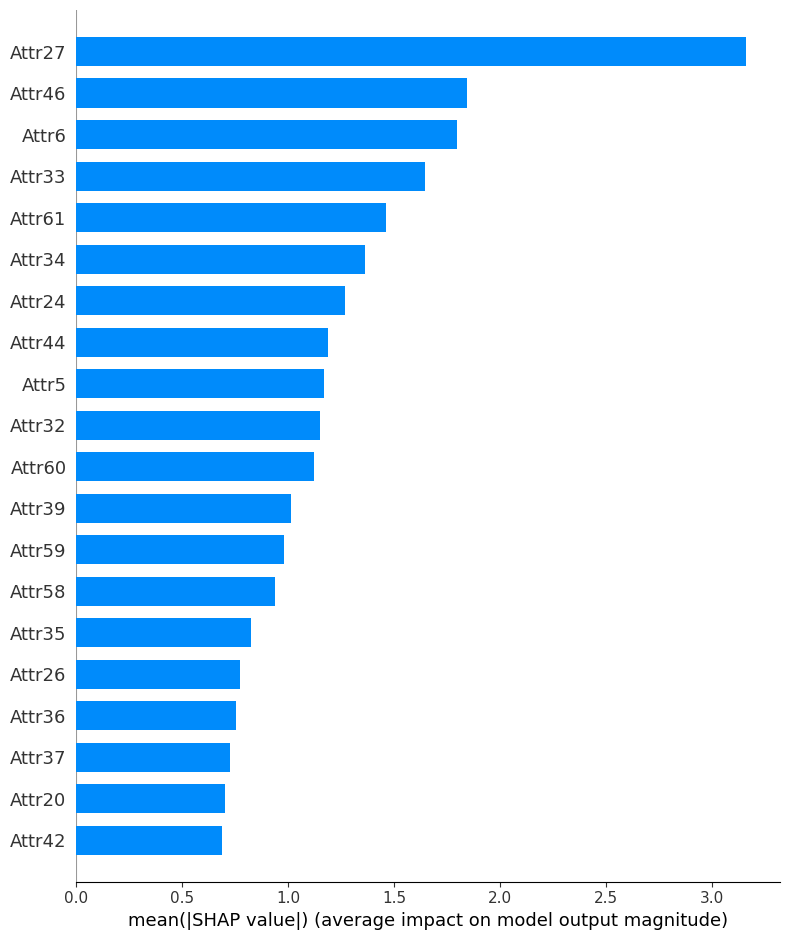

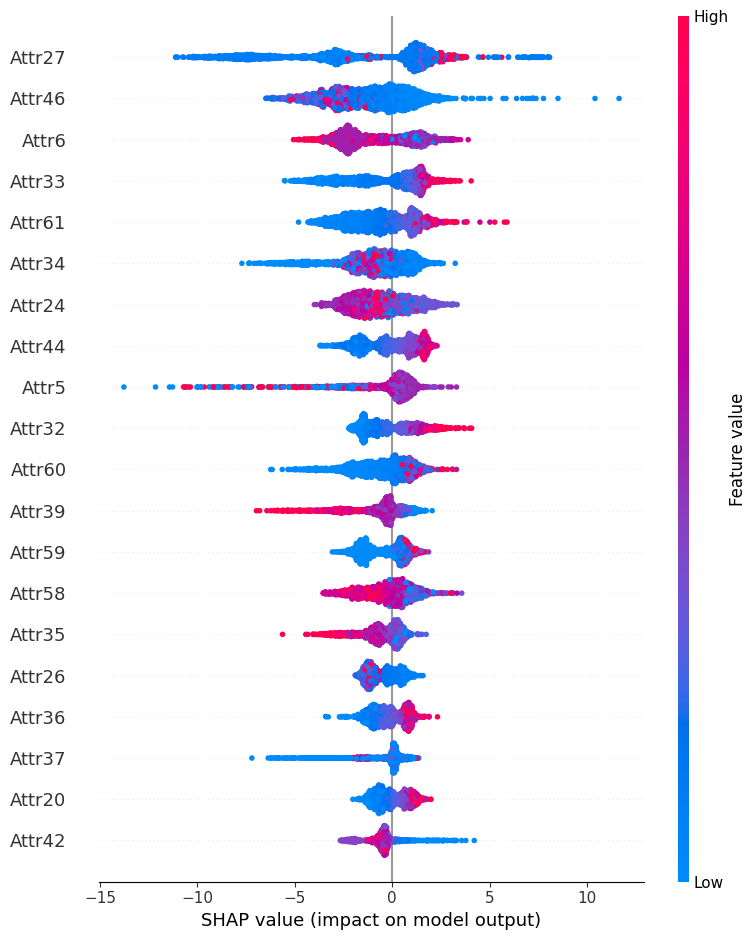

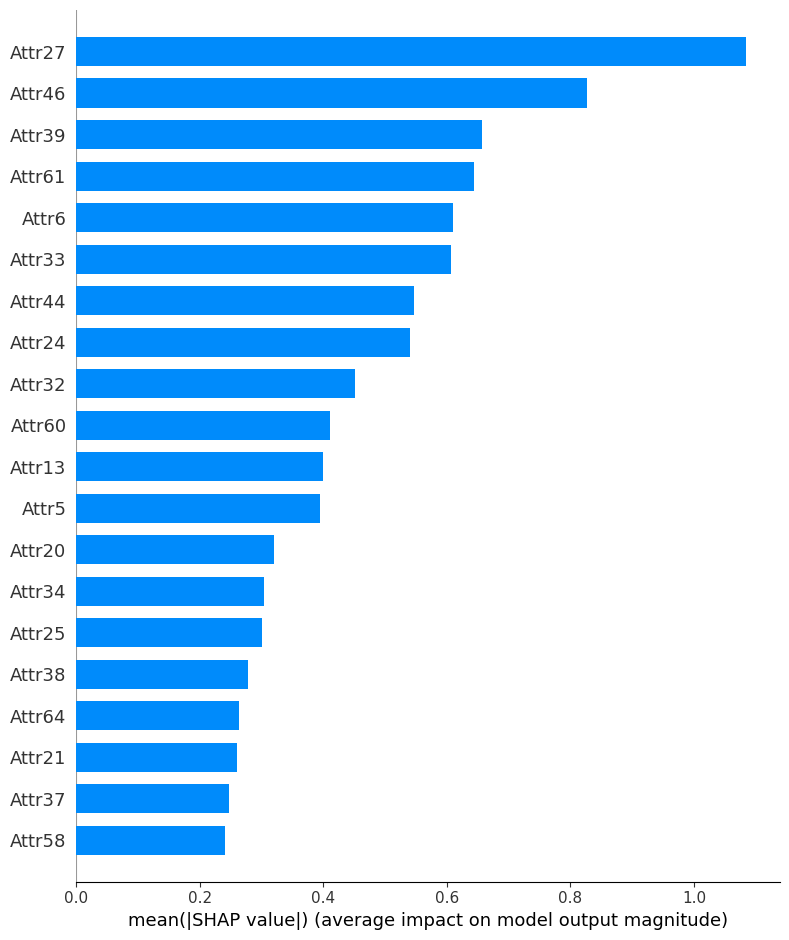

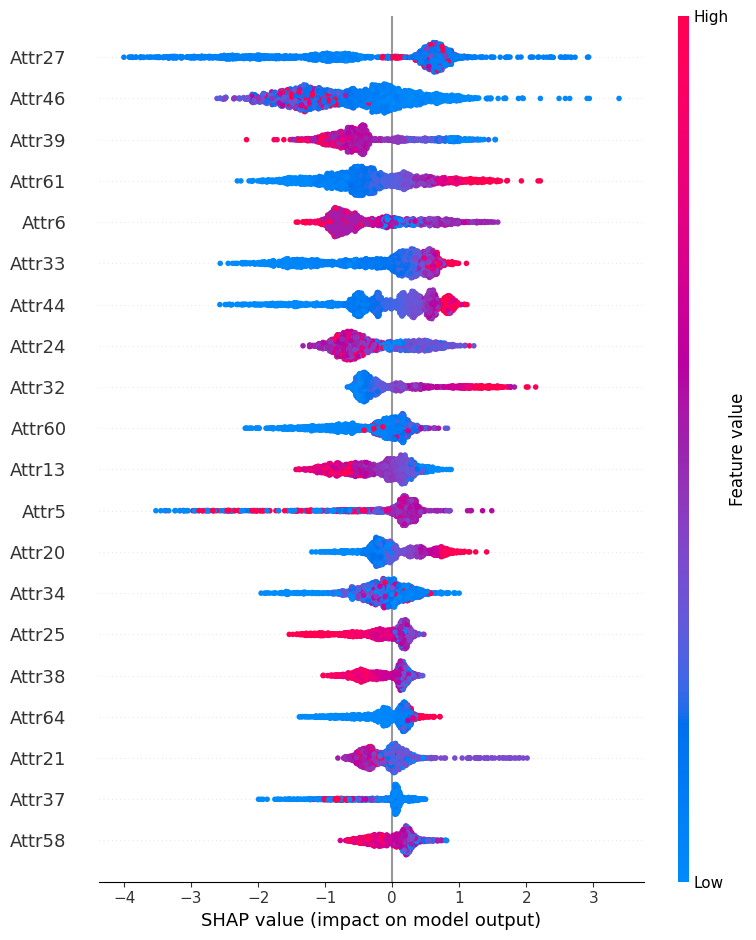

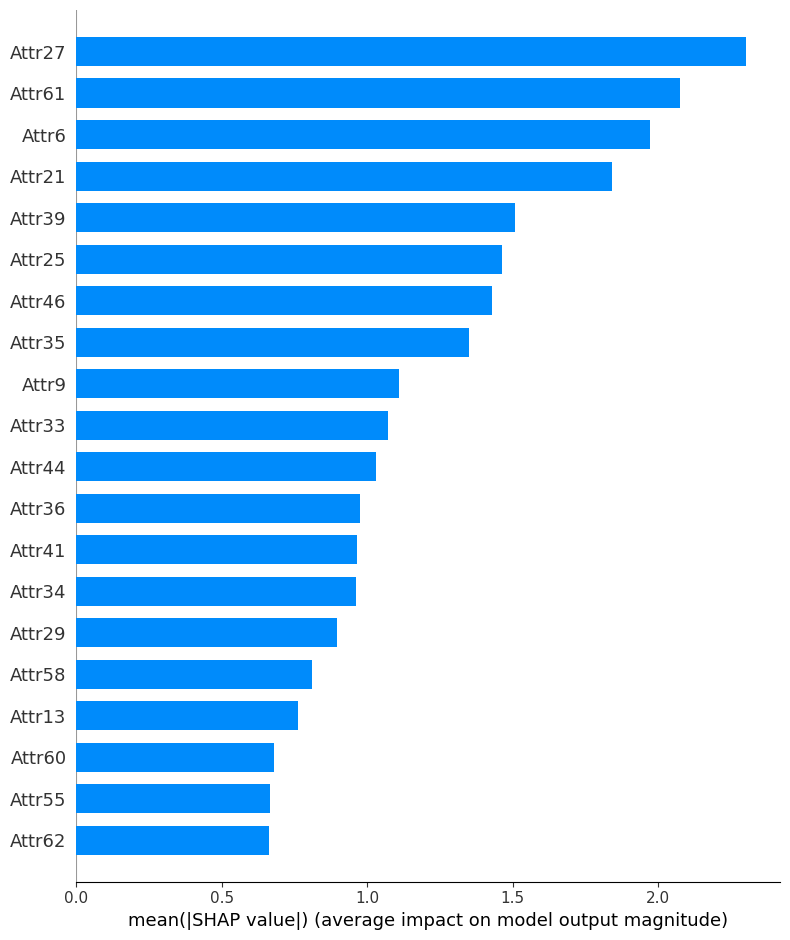

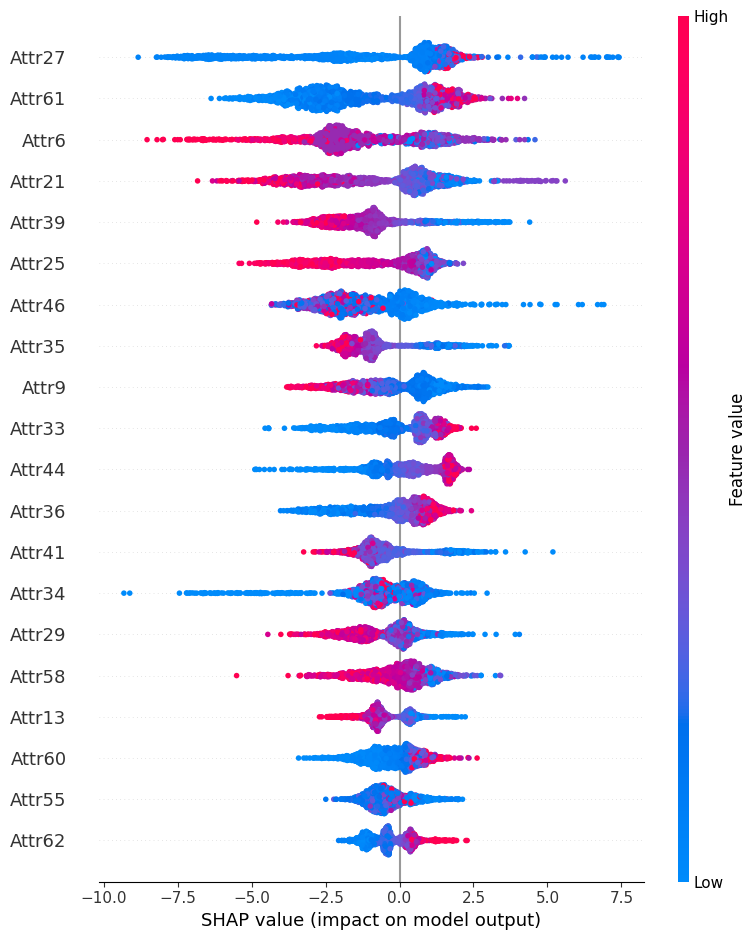

,Feature,MeanAbsSHAP,Horizon
0,Attr27,3.912270,1year
1,Attr46,2.021798,1year
2,Attr24,1.950735,1year
3,Attr6,1.736129,1year
4,Attr34,1.412154,1year
5,Attr61,1.359446,1year
6,Attr60,1.328914,1year
7,Attr44,1.314720,1year
8,Attr33,1.144838,1year
9,Attr5,1.032847,1year


In [13]:

def shap_global_plots(tree_model_pipe, X_train: pd.DataFrame, horizon: str, model_name: str, max_samples: int = 2000):
    # Extract fitted model (pipeline last step)
    model = tree_model_pipe.named_steps["model"]

    # Preprocess X the same way as pipeline (imputer + scaler)
    imputer = tree_model_pipe.named_steps["imputer"]
    scaler = tree_model_pipe.named_steps["scaler"]

    X_imp = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_scl = pd.DataFrame(scaler.transform(X_imp), columns=X_train.columns, index=X_train.index)

    # Subsample for SHAP
    if len(X_scl) > max_samples:
        X_scl_s = X_scl.sample(n=max_samples, random_state=RANDOM_STATE)
    else:
        X_scl_s = X_scl

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scl_s)

    # Bar (global)
    plt.figure()
    shap.summary_plot(shap_values, X_scl_s, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"fig_shap_bar_{model_name.lower()}_{horizon}.png"), dpi=300)
    plt.show()

    # Beeswarm
    plt.figure()
    shap.summary_plot(shap_values, X_scl_s, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"fig_shap_beeswarm_{model_name.lower()}_{horizon}.png"), dpi=300)
    plt.show()

# Run SHAP for LightGBM tuned across horizons
for h, df in datasets.items():
    X = df.drop(columns=["class"])
    y = df["class"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    tuned_pipe = best_store[(h, "LightGBM")]
    # Ensure fitted for SHAP (fit on training only)
    tuned_pipe.fit(X_train, y_train)
    shap_global_plots(tuned_pipe, X_train, horizon=h, model_name="LightGBM")

# Export: Top features table for the Abstract/Conclusion (mean absolute SHAP)
def shap_top_features(tree_model_pipe, X_train: pd.DataFrame, top_k: int = 10, max_samples: int = 2000) -> pd.DataFrame:
    model = tree_model_pipe.named_steps["model"]
    imputer = tree_model_pipe.named_steps["imputer"]
    scaler = tree_model_pipe.named_steps["scaler"]

    X_imp = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_scl = pd.DataFrame(scaler.transform(X_imp), columns=X_train.columns, index=X_train.index)

    if len(X_scl) > max_samples:
        X_scl_s = X_scl.sample(n=max_samples, random_state=RANDOM_STATE)
    else:
        X_scl_s = X_scl

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scl_s)

    mean_abs = np.mean(np.abs(shap_values), axis=0)
    order = np.argsort(mean_abs)[::-1][:top_k]
    return pd.DataFrame({
        "Feature": [X_train.columns[i] for i in order],
        "MeanAbsSHAP": [float(mean_abs[i]) for i in order],
    })

top_rows = []
for h, df in datasets.items():
    X = df.drop(columns=["class"])
    y = df["class"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    tuned_pipe = best_store[(h, "LightGBM")]
    tuned_pipe.fit(X_train, y_train)
    top_df = shap_top_features(tuned_pipe, X_train, top_k=10, max_samples=1500 if FAST_MODE else 2000)
    top_df["Horizon"] = h
    top_rows.append(top_df)

top_features_all = pd.concat(top_rows, ignore_index=True)
top_features_all.to_csv(os.path.join(TAB_DIR, "top_features_mean_abs_shap_lightgbm.csv"), index=False)
top_features_all.head(20)


## 9. Export: final artefacts for your report

- Tables in `outputs_bankruptcy/tables/`
- Figures in `outputs_bankruptcy/figures/`

Use these files directly in your report to prevent number/figure mismatches.

In [14]:
print('Figures saved in:', FIG_DIR)
print('Tables saved in:', TAB_DIR)
print('Example files:', sorted(os.listdir(FIG_DIR))[:10])

Figures saved in: outputs_bankruptcy\figures
Tables saved in: outputs_bankruptcy\tables
Example files: ['1year_lightgbm_tuned_confusion_matrix.png', '1year_lightgbm_tuned_roc_curve.png', '2year_lightgbm_tuned_confusion_matrix.png', '2year_lightgbm_tuned_roc_curve.png', '3year_lightgbm_tuned_confusion_matrix.png', '3year_lightgbm_tuned_roc_curve.png', '4year_lightgbm_tuned_confusion_matrix.png', '4year_lightgbm_tuned_roc_curve.png', '5year_lightgbm_tuned_confusion_matrix.png', '5year_lightgbm_tuned_roc_curve.png']


In [15]:
import os
os.listdir("outputs_bankruptcy/figures")

['1year_lightgbm_tuned_confusion_matrix.png',
 '1year_lightgbm_tuned_roc_curve.png',
 '2year_lightgbm_tuned_confusion_matrix.png',
 '2year_lightgbm_tuned_roc_curve.png',
 '3year_lightgbm_tuned_confusion_matrix.png',
 '3year_lightgbm_tuned_roc_curve.png',
 '4year_lightgbm_tuned_confusion_matrix.png',
 '4year_lightgbm_tuned_roc_curve.png',
 '5year_lightgbm_tuned_confusion_matrix.png',
 '5year_lightgbm_tuned_roc_curve.png',
 'fig_auc_catboost_baseline_vs_tuned.png',
 'fig_auc_delta_all_models.png',
 'fig_auc_lightgbm_baseline.png',
 'fig_auc_lightgbm_baseline_vs_tuned.png',
 'fig_auc_logreg_baseline.png',
 'fig_auc_xgboost_baseline_vs_tuned.png',
 'fig_bankruptcy_rate_by_horizon.png',
 'fig_missingness_pct_by_horizon.png',
 'fig_shap_bar_lightgbm_1year.png',
 'fig_shap_bar_lightgbm_2year.png',
 'fig_shap_bar_lightgbm_3year.png',
 'fig_shap_bar_lightgbm_4year.png',
 'fig_shap_bar_lightgbm_5year.png',
 'fig_shap_beeswarm_lightgbm_1year.png',
 'fig_shap_beeswarm_lightgbm_2year.png',
 'fig_sh